In [6]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score,RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

In [7]:
import pickle
with open("./temp_data/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)
with open("./temp_data/gb_median.pkl", "rb") as f:
    gb_median = pickle.load(f)
with open("./temp_data/gb_mean.pkl", "rb") as f:
    gb_mean = pickle.load(f)
with open("./temp_data/mlp_median.pkl", "rb") as f:
    mlp_median = pickle.load(f)
with open("./temp_data/mlp_mean.pkl", "rb") as f:
    mlp_mean = pickle.load(f)

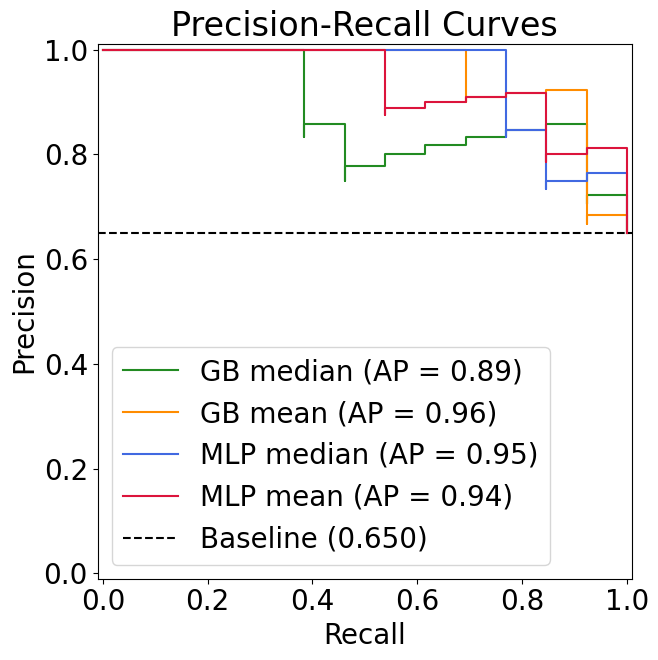

In [8]:
# Curvas Precision-Recall superpuestas para los 4 modelos
proba_models = {
    "GB median": gb_median,
    "GB mean": gb_mean,
    "MLP median": mlp_median,
    "MLP mean": mlp_mean,
}

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["forestgreen", "darkorange", "royalblue", "crimson"]

for (name, y_test_proba), color in zip(proba_models.items(), colors):
    ap_score = average_precision_score(y_test, y_test_proba)
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=f"{name}",
        ax=ax,
        color=color,
    )

baseline = sum(y_test) / len(y_test)
ax.axhline(
    baseline,
    linestyle="--",
    color="black",
    label=f"Baseline ({baseline:.3f})",
)

ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

c:\Universidad\1\Universidad\TFG\TFG-Towards-Explainable-AI\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Universidad\1\Universidad\TFG\TFG-Towards-Explainable-AI\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Universidad\1\Universidad\TFG\TFG-Towards-Explainable-AI\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Universidad\1\Universidad\TFG\TFG-Towards-Explainable-AI\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in

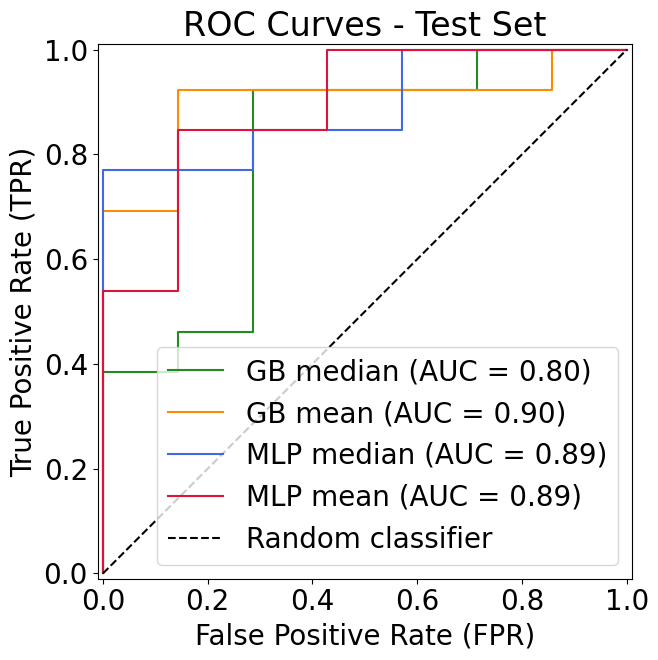

In [9]:
# Curvas ROC superpuestas para los 4 modelos
proba_models = {
    "GB median": gb_median,
    "GB mean": gb_mean,
    "MLP median": mlp_median,
    "MLP mean": mlp_mean,
}

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["forestgreen", "darkorange", "royalblue", "crimson"]

for (name, y_test_proba), color in zip(proba_models.items(), colors):
    roc_auc = roc_auc_score(y_test, y_test_proba)
    RocCurveDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=f"{name}",
        ax=ax,
        color=color,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random classifier")
ax.set_title("ROC Curves - Test Set")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()